In [42]:
import tensorflow as tf
import pandas as pd
import numpy as np
# 성적데이터.csv 파일을 열어 pandas의 데이터프레임으로 변환
df = pd.read_csv('성적데이터.csv')

# 독립변수, 종속변수 분리
# 독립변수 중 hour와 absent만 빼내서 X로
# 종속변수는 score
X = df[['hour', 'absent']]
# score가 60이상이면 1로, 미만이면 0으로 변경, 열 이름은 pass
def convert_pass(x):
    return 1 if x >= 60 else 0
df['pass1'] = df['score'].apply(convert_pass)
df['pass2'] = df['score'].apply(lambda x: 1 if x >= 60 else 0)
df['pass3'] = np.where(df['score'] >= 60, 1, 0)

y = df['pass3']


In [43]:
# 모델 설계
# 방법1. 레이어를 리스트로 한번에 넣어줌 : 직관적

# 정규화를 해주는 객체
# -1은 데이터의 마지막 차원을 기준으로 정규화
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(X.values.astype('float32'))

model1 = tf.keras.models.Sequential([
    normalizer, # 입력층으로 정규화 진행
    tf.keras.layers.Dense(4, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
# 방법2. add() 메소드를 통해 레이어를 추가 : 동적으로 작업
model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.Dense(4, activation='relu', input_shape=(2,)))
model2.add(tf.keras.layers.Dense(8, activation='relu'))
model2.add(tf.keras.layers.Dense(4, activation='relu'))
model2.add(tf.keras.layers.Dense(1, activation='sigmoid'))

C:\Users\hi6\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
# 모델 설정
# 1옵티마이저 설정 : 가중치를 업데이트 하는 방법을 설정 (adam, sgv, softmax등)
# 손실함수 : 오차를 계산하는 방법을 설정 (mse, binary_crossentropy 등)
# 평가지표 : 학습 중 사용자에게 보여줄 성적표 (accuracy 등)
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [45]:
# 학습
history = model1.fit(X, y, epochs=1000, batch_size=4, validation_split=0.2, verbose=0)

In [46]:
# (공부시간, 결석일) (5,0), (10,5), (8,1) 합격여부를 예측
predictions = model1.predict(np.array([[5,0],[10,5], [8,1]]))
print(f'학습시간: {5}, 결석일: {0}, 합격확률: {predictions[0][0]:.2f}')
print(f'학습시간: {10}, 결석일: {5}, 합격확률: {predictions[1][0]:.2f}')
print(f'학습시간: {8}, 결석일: {1}, 합격확률: {predictions[2][0]:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
학습시간: 5, 결석일: 0, 합격확률: 0.07
학습시간: 10, 결석일: 5, 합격확률: 0.94
학습시간: 8, 결석일: 1, 합격확률: 1.00


In [48]:
# accuracy: 정확도
# loss: 훈련 데이터 오차
# val_accuracy: 테스트(검증)데이터 정확도
# val_loss: 테스트(검증)데이터 오차
print(history.history.keys())


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


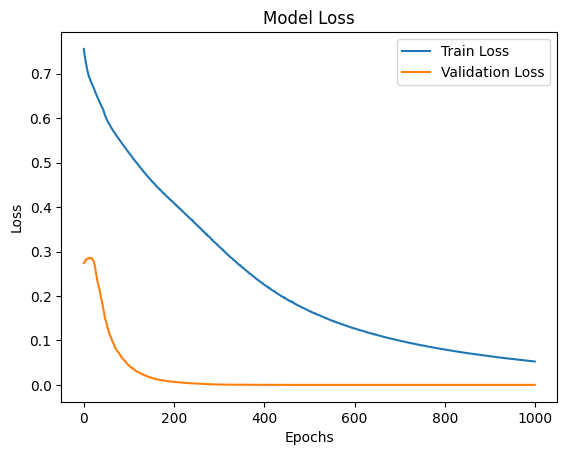

In [51]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# 최종 평가
df2 = pd.DataFrame({
    'hour': [4, 5.5, 8.5], 
    'absent': [0, 3, 3], 
    'pass': [0, 0, 1]
})
df2

,hour,absent,pass
0,4.0,0,0
1,5.5,3,0
2,8.5,3,1
